In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [18]:
path1 = r"Tabela5-sem_emprego_2012.csv"
path2 = r"Tabela5-sem_emprego_2026.csv"
path3 = r"Tabela 1.1.1.xls"

In [19]:
tabela12 = pd.read_csv(path1, sep = ";", encoding="utf-8", decimal=",", header= 0)
tabela26 = pd.read_csv(path2, sep = ";", encoding="utf-8", decimal=",", header= 0)
tab = pd.read_excel(path3, engine="xlrd")
tabela26

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [14]:
tabela12 = tabela12.rename(columns = {"Desocupados - homens (2012 T1)" : "Homens 2012"})
tabela12 = tabela12.rename(columns = {"Desocupados - mulheres (2012 T1)" : "Mulheres 2012"})
tabela12

,Sigla,Código,Estado,Homens 2012,Mulheres 2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [15]:
tabela26 = tabela26.rename(columns = {"Desocupados - homens (2026 T1)" : "Homens 2026"})
tabela26 = tabela26.rename(columns = {"Desocupados - mulheres (2026 T1)" : "Mulheres 2026"})
tabela26

,Sigla,Código,Estado,Homens 2026,Mulheres 2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [16]:
comp = tabela12.merge(tabela26, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,Homens 2012,Mulheres 2012,Homens 2026,Mulheres 2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [22]:

bruto = pd.read_excel(path3, engine="xlrd", header=None)


indicador1 = bruto.iloc[8:41].copy()

indicador1.columns = [
    "Estado",
    "Total",
    "Total Branca",
    "Total Preta Parda",
    "Homem Branca",
    "Homem Preta Parda",
    "Mulher Branca",
    "Mulher Preta Parda",
]

indicador1 = indicador1.reset_index(drop=True)

cols_numericas = indicador1.columns[1:]
indicador1[cols_numericas] = indicador1[cols_numericas].apply(pd.to_numeric, errors="coerce")

indicador1


,Estado,Total,Total Branca,Total Preta Parda,Homem Branca,Homem Preta Parda,Mulher Branca,Mulher Preta Parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [23]:
comp1 = comp.merge(indicador1, on=["Estado"], how="inner")
comp1

,Sigla,Código,Estado,Homens 2012,Mulheres 2012,Homens 2026,Mulheres 2026,Total,Total Branca,Total Preta Parda,Homem Branca,Homem Preta Parda,Mulher Branca,Mulher Preta Parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106,16.510610,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [25]:
ordem = comp1.sort_values("Mulheres 2026")["Estado"]
ordem

16                  Piauí
0                    Acre
5                   Ceará
3                   Amapá
1                 Alagoas
9                Maranhão
14                Paraíba
15             Pernambuco
10           Minas Gerais
13                   Pará
19    Rio Grande do Norte
6        Distrito Federal
7          Espírito Santo
8                   Goiás
22      Rio Grande do Sul
2                Amazonas
17                 Paraná
26              Tocantins
25              São Paulo
18         Rio de Janeiro
11     Mato Grosso do Sul
4                   Bahia
23         Santa Catarina
21                Roraima
12            Mato Grosso
24                Sergipe
20               Rondônia
Name: Estado, dtype: str

In [28]:
longo = comp.melt(
    id_vars=["Sigla","Código","Estado"],
    value_vars=["Mulheres 2012", "Mulheres 2026"],
    var_name="Ano",
    value_name="Participacao Mulheres",
)
longo["Ano"] = longo["Ano"].map({"Mulheres 2012": "2012 T1", "Mulheres 2026": "2026 T1"})
longo

,Sigla,Código,Estado,Ano,Participacao Mulheres
0,AC,12,Acre,2012 T1,54.7
1,AL,27,Alagoas,2012 T1,55.3
2,AM,13,Amazonas,2012 T1,52.5
3,AP,16,Amapá,2012 T1,51.9
4,BA,29,Bahia,2012 T1,56.2
5,CE,23,Ceará,2012 T1,48.9
6,DF,53,Distrito Federal,2012 T1,59.0
7,ES,32,Espírito Santo,2012 T1,53.6
8,GO,52,Goiás,2012 T1,59.0
9,MA,21,Maranhão,2012 T1,52.8


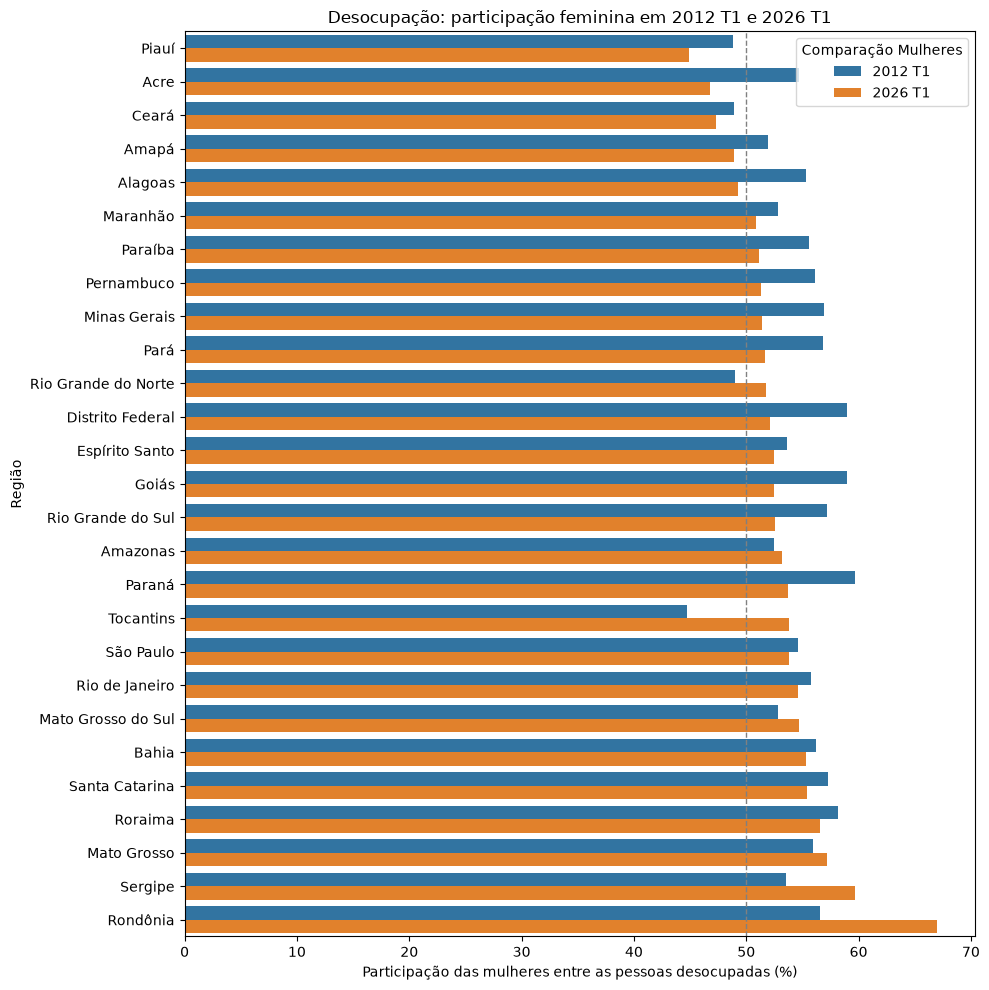

In [33]:

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao Mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="gray", linestyle="--", linewidth=1) # MUDE A COR
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("Região")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Comparação Mulheres")
fig.tight_layout()
plt.show()